In [1]:
import random
import pandas as pd
from datetime import datetime, timedelta
!pip install pandas matplotlib seaborn


def generate_synthetic_record():
    sim_swap_time_gap_minutes = random.randint(0, 10080)  # up to 7 days
    device_change_flag = random.choice([0, 1])
    sim_type_change_flag = random.choice([0, 1])
    imsi_change_flag = random.choice([0, 1])
    iccid_change_flag = random.choice([0, 1])
    otp_and_sim_change_geo_hash_length = round(random.uniform(0.0, 1.0), 2)

    # New features
    recent_sim_activation_days = random.randint(0, 365)
    num_sim_changes_last_30d = random.randint(0, 5)
    previous_sim_holder_tenure_days = random.randint(0, 1095)  # Up to 3 years
    account_age_days = random.randint(1, 1825)  # Up to 5 years
    ip_change_flag = random.choice([0, 1])

    # Sim swap flag logic (simple heuristic)
    identity_shift_score = device_change_flag + sim_type_change_flag + imsi_change_flag + iccid_change_flag
    geo_risk_score = 1 - otp_and_sim_change_geo_hash_length
    time_urgency_score = 1 - min(sim_swap_time_gap_minutes, 10080) / 10080

    fraud_score = (
            0.3 * identity_shift_score +
            0.2 * geo_risk_score +
            0.2 * time_urgency_score +
            0.1 * (1 if recent_sim_activation_days < 7 else 0) +
            0.1 * (1 if num_sim_changes_last_30d >= 2 else 0) +
            0.1 * ip_change_flag
    )
    sim_swap_flag = 1 if fraud_score > 0.7 else 0

    return {
        "sim_swap_time_gap_minutes": sim_swap_time_gap_minutes,
        "device_change_flag": device_change_flag,
        "sim_type_change_flag": sim_type_change_flag,
        "imsi_change_flag": imsi_change_flag,
        "iccid_change_flag": iccid_change_flag,
        "otp_and_sim_change_geo_hash_length": otp_and_sim_change_geo_hash_length,
        "recent_sim_activation_days": recent_sim_activation_days,
        "num_sim_changes_last_30d": num_sim_changes_last_30d,
        "previous_sim_holder_tenure_days": previous_sim_holder_tenure_days,
        "account_age_days": account_age_days,
        "ip_change_flag": ip_change_flag,
        "sim_swap_flag": sim_swap_flag
    }


def generate_dataset(n=50000):
    return pd.DataFrame([generate_synthetic_record() for _ in range(n)])


if __name__ == "__main__":
    df = generate_dataset(50000)
    df.to_csv("sim_swap_fraud_dataset_50000.csv", index=False)
    print("Dataset with 50,000 records saved as 'sim_swap_fraud_dataset_50000.csv'")


Dataset with 50,000 records saved as 'sim_swap_fraud_dataset_50000.csv'


In [2]:
import pandas as pd

# Load the labeled dataset (with 'sim_swap_flag')
df_raw = pd.read_csv("sim_swap_fraud_dataset_50000.csv")

# Preview the dataset
df_raw.head()

,sim_swap_time_gap_minutes,device_change_flag,sim_type_change_flag,imsi_change_flag,iccid_change_flag,otp_and_sim_change_geo_hash_length,recent_sim_activation_days,num_sim_changes_last_30d,previous_sim_holder_tenure_days,account_age_days,ip_change_flag,sim_swap_flag
0,8756,1,1,0,0,0.32,357,0,732,905,0,1
1,2808,0,0,1,1,0.29,224,3,542,497,0,1
2,7437,1,0,0,0,0.78,231,0,815,1155,0,0
3,3793,0,0,1,1,0.42,226,5,365,529,1,1
4,967,1,0,0,1,0.17,93,0,1086,830,0,1


In [3]:
# Re-import necessary libraries (if needed)
import pandas as pd

# Load the original dataset
df_raw = pd.read_csv("sim_swap_fraud_dataset_50000.csv")

# Define enrichment function
def enrich_input(raw):
    enriched = raw.copy()

    # Time urgency
    enriched['time_urgency_score'] = 1 - min(raw['sim_swap_time_gap_minutes'], 10080) / 10080

    # Identity shift score
    enriched['identity_shift_score'] = sum([
        raw['device_change_flag'],
        raw['sim_type_change_flag'],
        raw['imsi_change_flag'],
        raw['iccid_change_flag']
    ])

    # FIX: Normalize or clamp geo distance
    MAX_ALLOWED_DISTANCE = 10000  # or tune based on domain
    normalized_geo_hash = min(raw['otp_and_sim_change_geo_hash_length'] / MAX_ALLOWED_DISTANCE, 1.0)
    enriched['geo_risk_score'] = 1 - normalized_geo_hash

    # Other enrichment
    enriched['sim_activity_score'] = 1 - min(raw['recent_sim_activation_days'], 365) / 365
    enriched['account_risk_score'] = (
        raw['num_sim_changes_last_30d'] * 0.3 +
        (1 - min(raw['previous_sim_holder_tenure_days'], 3650) / 3650) * 0.3 +
        (1 - min(raw['account_age_days'], 3650) / 3650) * 0.3 +
        raw['ip_change_flag'] * 0.1
    )

    return enriched


# Apply enrichment to all rows
df_enriched = df_raw.apply(enrich_input, axis=1)

# Confirm new columns exist
df_enriched.head()


,sim_swap_time_gap_minutes,device_change_flag,sim_type_change_flag,imsi_change_flag,iccid_change_flag,otp_and_sim_change_geo_hash_length,recent_sim_activation_days,num_sim_changes_last_30d,previous_sim_holder_tenure_days,account_age_days,ip_change_flag,sim_swap_flag,time_urgency_score,identity_shift_score,geo_risk_score,sim_activity_score,account_risk_score
0,8756.0,1.0,1.0,0.0,0.0,0.32,357.0,0.0,732.0,905.0,0.0,1.0,0.131349,2.0,0.999968,0.021918,0.465452
1,2808.0,0.0,0.0,1.0,1.0,0.29,224.0,3.0,542.0,497.0,0.0,1.0,0.721429,2.0,0.999971,0.386301,1.414603
2,7437.0,1.0,0.0,0.0,0.0,0.78,231.0,0.0,815.0,1155.0,0.0,0.0,0.262202,1.0,0.999922,0.367123,0.438082
3,3793.0,0.0,0.0,1.0,1.0,0.42,226.0,5.0,365.0,529.0,1.0,1.0,0.623710,2.0,0.999958,0.380822,2.126521
4,967.0,1.0,0.0,0.0,1.0,0.17,93.0,0.0,1086.0,830.0,0.0,1.0,0.904067,2.0,0.999983,0.745205,0.442521


/tmp/ipython-input-3523475713.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x="sim_swap_flag", palette="Set2")


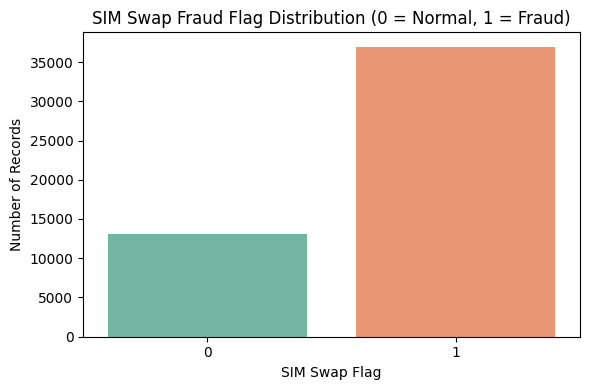

        Class  Percentage
0   Fraud (1)      73.872
1  Normal (0)      26.128


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have already generated or loaded the dataset
# If not, uncomment the line below and load the CSV
# df_raw = pd.read_csv("sim_swap_fraud_dataset_50000.csv")

# Bar chart for fraud flag distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df_raw, x="sim_swap_flag", palette="Set2")
plt.title("SIM Swap Fraud Flag Distribution (0 = Normal, 1 = Fraud)")
plt.xlabel("SIM Swap Flag")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

# Display class distribution in percentage
fraud_counts = df_raw["sim_swap_flag"].value_counts(normalize=True) * 100
fraud_counts = fraud_counts.rename({0: "Normal (0)", 1: "Fraud (1)"})
fraud_counts_df = fraud_counts.reset_index()
fraud_counts_df.columns = ["Class", "Percentage"]

# Display as table
print(fraud_counts_df)


## **Analysis on Dataset and inut feature enrichment **

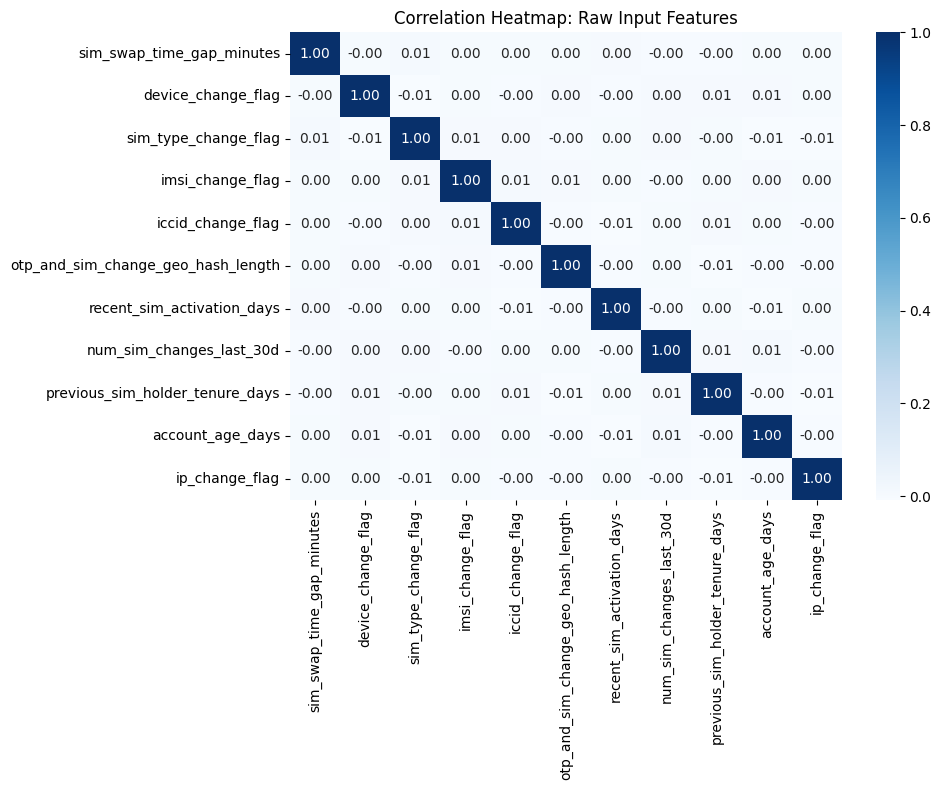

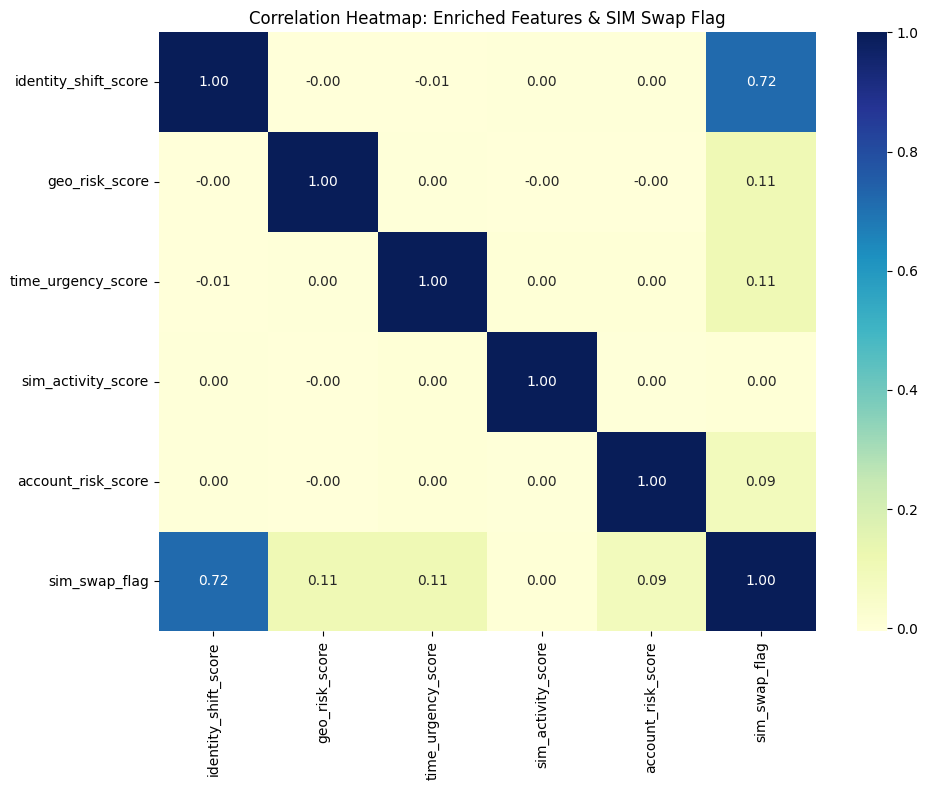

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_enriched["sim_swap_flag"] = df_raw["sim_swap_flag"]

# === 1. Correlation Heatmap for Raw Input Features ===
raw_features = [
    "sim_swap_time_gap_minutes", "device_change_flag", "sim_type_change_flag",
    "imsi_change_flag", "iccid_change_flag", "otp_and_sim_change_geo_hash_length",
    "recent_sim_activation_days", "num_sim_changes_last_30d",
    "previous_sim_holder_tenure_days", "account_age_days", "ip_change_flag"
]

plt.figure(figsize=(10, 8))
sns.heatmap(df_raw[raw_features].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap: Raw Input Features")
plt.tight_layout()
plt.show()

# === 2. Correlation Heatmap for Enriched Features + Target ===
enriched_features = [
    "identity_shift_score", "geo_risk_score", "time_urgency_score",
    "sim_activity_score", "account_risk_score", "sim_swap_flag"
]

plt.figure(figsize=(10, 8))
sns.heatmap(df_enriched[enriched_features].corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Heatmap: Enriched Features & SIM Swap Flag")
plt.tight_layout()
plt.show()



In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Features and label
feature_columns = [
    "sim_swap_time_gap_minutes",
    "device_change_flag",
    "sim_type_change_flag",
    "imsi_change_flag",
    "iccid_change_flag",
    "otp_and_sim_change_geo_hash_length",
    "recent_sim_activation_days",
    "num_sim_changes_last_30d",
    "previous_sim_holder_tenure_days",
    "account_age_days",
    "ip_change_flag"
]
label_column = "sim_swap_flag"

X = df_enriched[feature_columns]
y = df_enriched[label_column]

# Step 1: Split into 70% train and 30% temp (for val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Step 2: Split the temp set into 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Testing set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Train the model on the training set
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully on 70% training data!")



Training set: 35000 samples (70.0%)
Validation set: 7500 samples (15.0%)
Testing set: 7500 samples (15.0%)
Model trained successfully on 70% training data!


In [5]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict on the test set
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_class = model.predict(X_test)

# Risk classification function
def classify_risk(prob):
    if prob >= 0.9:
        return "Very High"
    elif prob >= 0.7:
        return "High"
    elif prob >= 0.4:
        return "Medium"
    elif prob >= 0.2:
        return "Low"
    else:
        return "Very Low"

# Assign risk levels
risk_levels = [classify_risk(p) for p in y_pred_proba]

# Prepare results DataFrame
results_df = X_test.copy()
results_df['Actual_Label'] = y_test.values
results_df['Predicted_Label'] = y_pred_class
results_df['Fraud_Probability'] = y_pred_proba
results_df['Risk_Level'] = risk_levels

results_df.head(10)


,sim_swap_time_gap_minutes,device_change_flag,sim_type_change_flag,imsi_change_flag,iccid_change_flag,otp_and_sim_change_geo_hash_length,recent_sim_activation_days,num_sim_changes_last_30d,previous_sim_holder_tenure_days,account_age_days,ip_change_flag,Actual_Label,Predicted_Label,Fraud_Probability,Risk_Level
47730,1614.0,0.0,1.0,1.0,1.0,0.17,305.0,5.0,701.0,793.0,0.0,1.0,1.0,1.00,Very High
39958,4145.0,0.0,0.0,0.0,1.0,0.96,73.0,5.0,1031.0,58.0,0.0,0.0,0.0,0.04,Very Low
21408,4817.0,1.0,0.0,0.0,0.0,0.17,60.0,3.0,861.0,1007.0,1.0,1.0,1.0,0.95,Very High
44819,7076.0,1.0,0.0,1.0,0.0,0.66,251.0,3.0,613.0,1639.0,0.0,1.0,1.0,0.97,Very High
27295,8549.0,0.0,0.0,1.0,0.0,0.10,307.0,1.0,80.0,1592.0,1.0,0.0,0.0,0.14,Very Low
44224,508.0,0.0,1.0,1.0,0.0,0.09,117.0,3.0,248.0,424.0,0.0,1.0,1.0,1.00,Very High
21572,2514.0,0.0,1.0,0.0,0.0,0.21,8.0,3.0,796.0,66.0,1.0,1.0,1.0,0.93,Very High
9701,3177.0,1.0,1.0,0.0,1.0,0.49,335.0,2.0,1046.0,897.0,0.0,1.0,1.0,1.00,Very High
23422,9476.0,0.0,1.0,1.0,0.0,1.00,90.0,0.0,986.0,807.0,0.0,0.0,0.0,0.36,Low
15725,1085.0,1.0,0.0,1.0,1.0,0.71,212.0,1.0,571.0,635.0,0.0,1.0,1.0,1.00,Very High


Evaluate Model Performance

Let’s look at the performance metrics like accuracy, precision, recall, and F1 score, along with the confusion matrix:

In [6]:
# Predict on validation set
y_val_pred = model.predict(X_val)
y_val_proba = model.predict_proba(X_val)[:, 1]

# Validation performance
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred, digits=4))

print("Confusion Matrix (Validation Set):")
print(confusion_matrix(y_val, y_val_pred))




Classification Report (Validation Set):
              precision    recall  f1-score   support

         0.0     0.9821    0.9806    0.9813      1955
         1.0     0.9932    0.9937    0.9934      5545

    accuracy                         0.9903      7500
   macro avg     0.9876    0.9871    0.9874      7500
weighted avg     0.9903    0.9903    0.9903      7500

Confusion Matrix (Validation Set):
[[1917   38]
 [  35 5510]]


In [7]:
from sklearn.metrics import accuracy_score

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9891


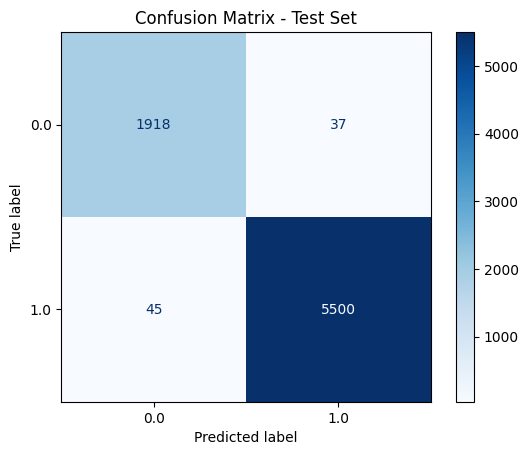

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Display with labels
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_class, cmap='Blues')
plt.title("Confusion Matrix - Test Set")
plt.show()


Visualize Risk Level Distribution

/tmp/ipython-input-865125901.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


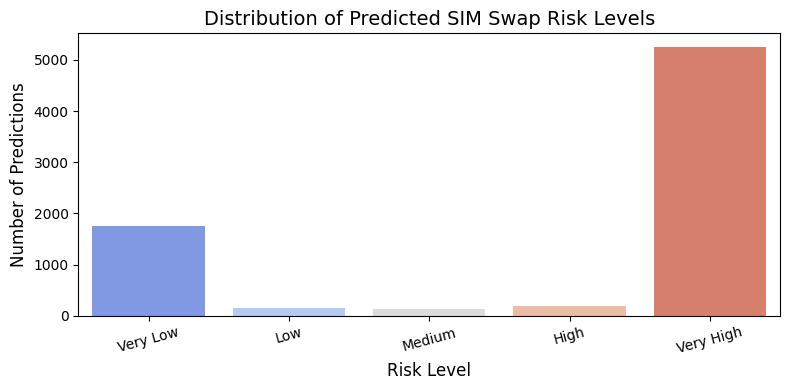

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.countplot(
    data=results_df,
    x="Risk_Level",
    order=["Very Low", "Low", "Medium", "High", "Very High"],
    palette="coolwarm"  # optional: adds color
)
plt.title("Distribution of Predicted SIM Swap Risk Levels", fontsize=14)
plt.xlabel("Risk Level", fontsize=12)
plt.ylabel("Number of Predictions", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



In [ ]:
import joblib

# Save the trained model
joblib.dump(model, "sim_swap_fraud_rf_model.pkl")
print("✅ Model saved to sim_swap_fraud_rf_model.pkl")


✅ Model saved to sim_swap_fraud_rf_model.pkl


In [ ]:
# Define a single raw input
custom_input = {
    "sim_swap_time_gap_minutes": 10,
    "device_change_flag": 0,
    "sim_type_change_flag": 0,
    "imsi_change_flag": 0,
    "iccid_change_flag": 0,
    "otp_and_sim_change_geo_hash_length": 10000,
    "recent_sim_activation_days": 356,
    "num_sim_changes_last_30d": 1,
    "previous_sim_holder_tenure_days": 300,
    "account_age_days": 10000,
    "ip_change_flag": 1
}

# Enrich the input
enriched_input = enrich_input(custom_input)
input_df = pd.DataFrame([enriched_input])

# Ensure input has the correct feature order
input_features = input_df[feature_columns]

# Predict using trained model
pred_proba = model.predict_proba(input_features)[0][1]  # Probability of fraud
pred_class = model.predict(input_features)[0]

# Map probability to risk level
def map_risk_level(prob):
    if prob >= 0.90:
        return "Very High"
    elif prob >= 0.70:
        return "High"
    elif prob >= 0.40:
        return "Medium"
    elif prob >= 0.20:
        return "Low"
    else:
        return "Very Low"

risk_level = map_risk_level(pred_proba)

# Show results
print(f"🔍 Predicted Fraud Probability: {pred_proba:.4f}")
print(f"🔒 Classified as: {risk_level} Risk")
print(f"📌 Model Binary Class Prediction: {pred_class} (1 = Fraud, 0 = Normal)")


🔍 Predicted Fraud Probability: 0.0300
🔒 Classified as: Very Low Risk
📌 Model Binary Class Prediction: 0.0 (1 = Fraud, 0 = Normal)
